In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

import shutil
HAS_LATEX = shutil.which('pdflatex') is not None

plt.rcParams.update({
    'text.usetex': HAS_LATEX,       # True when pdflatex available, renders Computer Modern
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 9,
    'mathtext.fontset': 'cm',
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

if not HAS_LATEX:
    print('Note: pdflatex not found — using mathtext fallback. '
          'Install TeX Live for full LaTeX rendering.')

client = bigquery.Client(project='broadband-data')
print(f'Ready (LaTeX: {HAS_LATEX})')

Note: pdflatex not found — using mathtext fallback. Install TeX Live for full LaTeX rendering.
Ready (LaTeX: False)


In [2]:
# Load and prepare data (same pipeline as bead_rf_final)
df_projects = client.query("""
SELECT project_id, state, bead_support, estimated_miles_aerial_fiber,
       estimated_miles_buried_fiber, estimated_jobs
FROM `broadband-data.fp_approved.deployment_projects`
""").to_dataframe()

df_locations = client.query("""
SELECT project_id, COUNT(*) AS funded_locations,
       SAFE_CAST(APPROX_TOP_COUNT(CAST(technology AS STRING), 1)[OFFSET(0)].value AS FLOAT64) AS technology
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
""").to_dataframe()

state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}
df_nbm = client.query("SELECT state, COUNT(DISTINCT frn) AS state_num_providers FROM `broadband-data.fcc_nbm.nbm_hive` GROUP BY state").to_dataframe()
df_nbm['state'] = df_nbm['state'].map(state_name_to_abbr)
df_nbm = df_nbm.dropna(subset=['state'])
df_state_pop = client.query("SELECT stateabbr AS state, SUM(pop2020) AS state_population FROM `broadband-data.fcc_block_level_pop.us2020` GROUP BY stateabbr").to_dataframe()

df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_nbm, on='state', how='left')
df = df.merge(df_state_pop, on='state', how='left')
df['funded_locations'] = df['funded_locations'].fillna(0)
df['technology'] = df['technology'].fillna(0)
df['state_num_providers'] = df['state_num_providers'].fillna(0)
df['state_population'] = df['state_population'].fillna(0)
df['total_fiber_miles'] = df['estimated_miles_aerial_fiber'].fillna(0) + df['estimated_miles_buried_fiber'].fillna(0)
df['miles_per_location'] = df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)
df['miles_per_location'] = df['miles_per_location'].fillna(0)
df['jobs_per_location'] = df['estimated_jobs'] / df['funded_locations'].replace(0, np.nan)
df['jobs_per_location'] = df['jobs_per_location'].fillna(0)
df['funding_per_location'] = df['bead_support'] / df['funded_locations'].replace(0, np.nan)
df = df.dropna(subset=['funding_per_location'])
low = df['funding_per_location'].quantile(0.025)
high = df['funding_per_location'].quantile(0.975)
df = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]
df['log_funding'] = np.log1p(df['funding_per_location'])

feature_cols = ['miles_per_location', 'technology', 'jobs_per_location',
                'state_population', 'total_fiber_miles', 'state_num_providers']
X = df[feature_cols].fillna(0)
y = df['log_funding']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f'Model trained: {len(rf.estimators_)} trees, {X_train.shape[0]} samples')

Model trained: 200 trees, 3473 samples


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

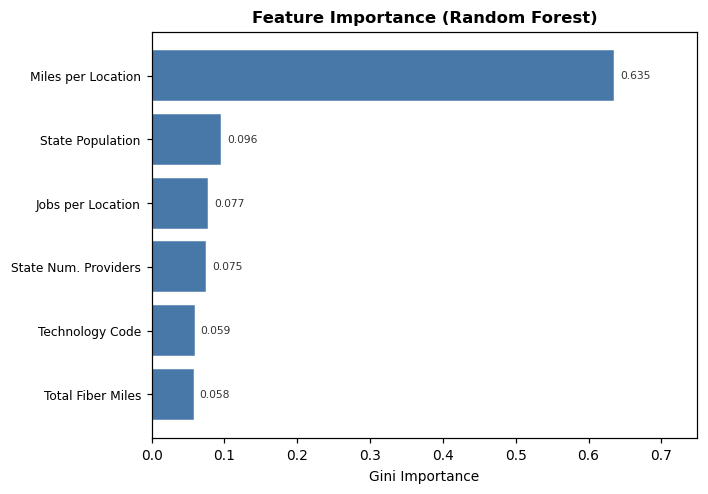

Saved: fig_feature_importance.pdf / .png


In [3]:
# ============================================================
# Figure 1: Feature Importance (Gini impurity-based)
# ============================================================
feat_labels = {
    'miles_per_location': 'Miles per Location',
    'technology': 'Technology Code',
    'jobs_per_location': 'Jobs per Location',
    'state_population': 'State Population',
    'total_fiber_miles': 'Total Fiber Miles',
    'state_num_providers': 'State Num. Providers',
}

imp = pd.Series(rf.feature_importances_, index=feature_cols)
imp.index = [feat_labels[f] for f in imp.index]
imp = imp.sort_values()

fig, ax = plt.subplots()
bars = ax.barh(imp.index, imp.values, color='#4878A8', edgecolor='white', linewidth=0.3)

# Annotate values
for bar, val in zip(bars, imp.values):
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7, color='#333')

ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance (Random Forest)', weight='bold')
ax.set_xlim(0, imp.max() * 1.18)
ax.tick_params(axis='y', labelsize=8)

plt.savefig('fig_feature_importance.pdf')
plt.savefig('fig_feature_importance.png')
plt.show()
print('Saved: fig_feature_importance.pdf / .png')

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

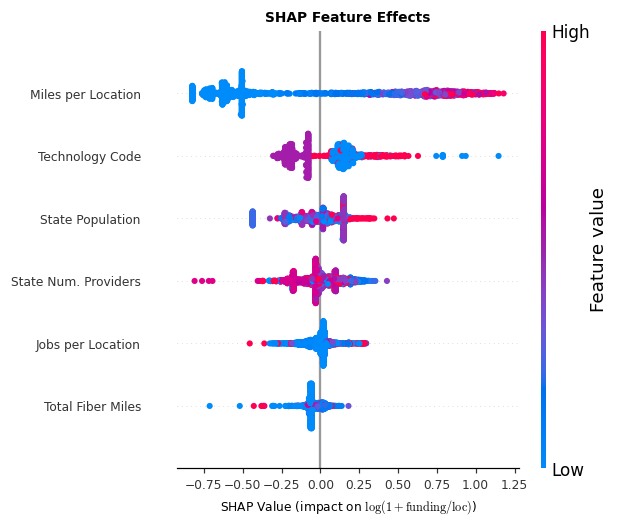

Saved: fig_shap_beeswarm.pdf / .png


In [4]:
# ============================================================
# Figure 2: SHAP Beeswarm Summary Plot
# ============================================================
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Rename features for display
display_names = [feat_labels[f] for f in feature_cols]

fig, ax = plt.subplots()
shap.summary_plot(shap_values, X_test, feature_names=display_names,
                  show=False, plot_size=None, max_display=6)
ax = plt.gca()
ax.set_xlabel('SHAP Value (impact on $\\log(1+\\mathrm{funding/loc})$)', fontsize=8)
ax.set_title('SHAP Feature Effects', weight='bold', fontsize=9)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)

plt.savefig('fig_shap_beeswarm.pdf')
plt.savefig('fig_shap_beeswarm.png')
plt.show()
print('Saved: fig_shap_beeswarm.pdf / .png')

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

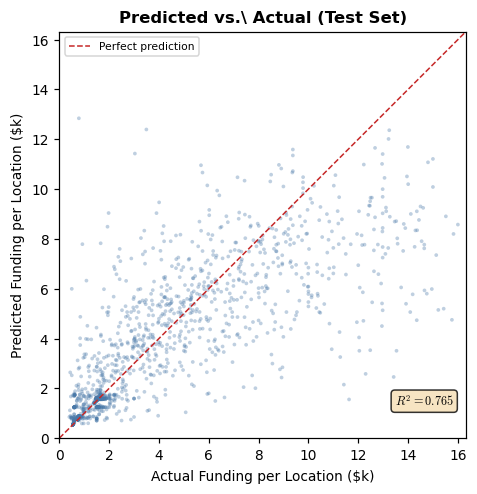

Saved: fig_pred_vs_actual.pdf / .png


In [5]:
# ============================================================
# Figure 3: Predicted vs Actual Scatter (test set)
# ============================================================
y_pred = rf.predict(X_test)
y_actual_dollar = np.expm1(y_test)
y_pred_dollar = np.expm1(y_pred)

fig, ax = plt.subplots()
ax.scatter(y_actual_dollar / 1000, y_pred_dollar / 1000,
           s=6, alpha=0.35, color='#4878A8', edgecolors='none', rasterized=True)

# 45-degree reference line
lims = [0, max(y_actual_dollar.max(), y_pred_dollar.max()) / 1000 * 1.02]
ax.plot(lims, lims, '--', color='#C62828', lw=1.0, label='Perfect prediction')

ax.set_xlabel('Actual Funding per Location (\\$k)')
ax.set_ylabel('Predicted Funding per Location (\\$k)')
ax.set_title('Predicted vs.\\ Actual (Test Set)', weight='bold')
ax.legend(fontsize=7, loc='upper left')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

r2 = r2_score(y_test, y_pred)
ax.text(0.97, 0.08, f'$R^2 = {r2:.3f}$',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

plt.savefig('fig_pred_vs_actual.pdf')
plt.savefig('fig_pred_vs_actual.png')
plt.show()
print('Saved: fig_pred_vs_actual.pdf / .png')

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


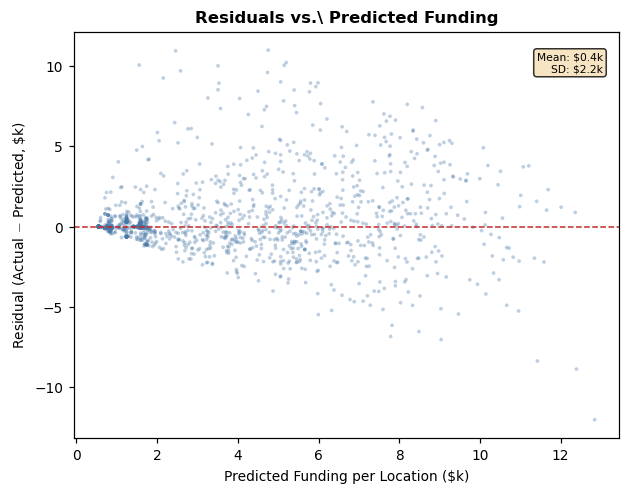

Saved: fig_residuals.pdf / .png


In [6]:
# ============================================================
# Figure 4: Residuals vs Predicted Funding
# ============================================================
residuals_dollar = y_actual_dollar - y_pred_dollar

fig, ax = plt.subplots()
ax.scatter(y_pred_dollar / 1000, residuals_dollar / 1000,
           s=6, alpha=0.35, color='#4878A8', edgecolors='none', rasterized=True)
ax.axhline(0, color='#C62828', lw=1.0, linestyle='--')

ax.set_xlabel('Predicted Funding per Location (\\$k)')
ax.set_ylabel('Residual (Actual $-$ Predicted, \\$k)')
ax.set_title('Residuals vs.\\ Predicted Funding', weight='bold')

# Annotate mean residual and std
mean_res = residuals_dollar.mean()
std_res = residuals_dollar.std()
ax.text(0.97, 0.95,
        f'Mean: \\${mean_res/1000:.1f}k\nSD: \\${std_res/1000:.1f}k',
        transform=ax.transAxes, ha='right', va='top', fontsize=7,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

plt.savefig('fig_residuals.pdf')
plt.savefig('fig_residuals.png')
plt.show()
print('Saved: fig_residuals.pdf / .png')